# Longformer Stance Detection — FNC-1

Fine-tuning `allenai/longformer-base-4096` for the Fake News Challenge (FNC-1) stance detection task.

**Key improvement**: Leakage-free data splitting using `GroupShuffleSplit` on Body ID to ensure no article body appears in both training and validation sets.

In [4]:
# Environment Configuration & Setup
# ENVIRONMENT = "kaggle"
ENVIRONMENT = "local"

if ENVIRONMENT == "kaggle":
    TRAIN_PATH = "/kaggle/input/datasets/deanfebrio/aol-textmining-fakenewsdetection-dataset/processed/train_processed.csv"
    TEST_PATH = "/kaggle/input/datasets/deanfebrio/aol-textmining-fakenewsdetection-dataset/processed/test_processed.csv"
    OUTPUT_DIR = "/kaggle/working/model/"
elif ENVIRONMENT == "local":
    TRAIN_PATH = "./data/processed/train_processed.csv"
    TEST_PATH = "./data/processed/test_processed.csv"
    OUTPUT_DIR = "./artifacts/model-longformer/"
else:
    raise ValueError(f"Unknown environment: {ENVIRONMENT}")

print(f"Environment: {ENVIRONMENT}")
print(f"Train path: {TRAIN_PATH}")
print(f"Test path: {TEST_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Environment: local
Train path: ./data/processed/train_processed.csv
Test path: ./data/processed/test_processed.csv
Output dir: ./artifacts/model-longformer/


In [5]:
if ENVIRONMENT == "kaggle":
  !pip install -q pandas numpy matplotlib seaborn scikit-learn torch transformers datasets accelerate tqdm

# Setup

Import library, konfigurasi random seed, dan deteksi device.

In [6]:
import pandas as pd
import numpy as np
import os

import torch
import transformers

# ==========================================
# MONKEY PATCH FOR DATAPARALLEL BUG
# ==========================================
# Patch PreTrainedModel.dtype to prevent StopIteration in DataParallel
@property
def patched_dtype(self):
    try:
        return next(param.dtype for param in self.parameters() if param.is_floating_point())
    except StopIteration:
        return torch.float32
transformers.modeling_utils.PreTrainedModel.dtype = patched_dtype
# ==========================================
from transformers import (
    LongformerTokenizerFast,
    LongformerForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time
import json
import warnings

warnings.filterwarnings("ignore")

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device detection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Torch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Device: {device}")

CUDA available: True
GPU name: NVIDIA GeForce RTX 2060
GPU memory: 6.4 GB
Torch version: 2.7.1+cu118
Transformers version: 4.57.6
Device: cuda


# Load Dataset

Memuat dataset training dan testing yang sudah dipreprocessing.

In [7]:
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print("=== Train Dataset ===")
print(f"Shape: {df_train.shape}")
print(f"Columns: {df_train.columns.tolist()}")

print("\n=== Test Dataset ===")
print(f"Shape: {df_test.shape}")
print(f"Columns: {df_test.columns.tolist()}")

# Verify required columns
for col in ["Headline", "articleBody", "Stance", "Body ID"]:
    assert col in df_train.columns, f"Missing column in train: {col}"
    print(f"Column '{col}' verified in train dataset")

for col in ["Headline", "articleBody"]:
    assert col in df_test.columns, f"Missing column in test: {col}"
    print(f"Column '{col}' verified in test dataset")

print("\n=== Label Distribution (Train) ===")
print(df_train["Stance"].value_counts())

print(f"\nUnique Body IDs in train: {df_train['Body ID'].nunique()}")

=== Train Dataset ===
Shape: (49972, 4)
Columns: ['Body ID', 'articleBody', 'Headline', 'Stance']

=== Test Dataset ===
Shape: (25413, 3)
Columns: ['Body ID', 'articleBody', 'Headline']
Column 'Headline' verified in train dataset
Column 'articleBody' verified in train dataset
Column 'Stance' verified in train dataset
Column 'Body ID' verified in train dataset
Column 'Headline' verified in test dataset
Column 'articleBody' verified in test dataset

=== Label Distribution (Train) ===
Stance
unrelated    36545
discuss       8909
agree         3678
disagree       840
Name: count, dtype: int64

Unique Body IDs in train: 1683


# Label Encoding

Mapping label stance ke nilai numerik untuk training.

In [8]:
label2id = {
    "agree": 0,
    "disagree": 1,
    "discuss": 2,
    "unrelated": 3,
}

id2label = {v: k for k, v in label2id.items()}

print("label2id:", label2id)
print("id2label:", id2label)

# Convert labels to numeric
df_train["label"] = df_train["Stance"].map(label2id)

print("\n=== Label Counts ===")
print(df_train["label"].value_counts().sort_index())

# Verify no NaN labels
assert df_train["label"].isna().sum() == 0, "Found unmapped labels!"
print("\nAll labels mapped successfully.")

label2id: {'agree': 0, 'disagree': 1, 'discuss': 2, 'unrelated': 3}
id2label: {0: 'agree', 1: 'disagree', 2: 'discuss', 3: 'unrelated'}

=== Label Counts ===
label
0     3678
1      840
2     8909
3    36545
Name: count, dtype: int64

All labels mapped successfully.


# Train Validation Split (Leakage-Free)

**CRITICAL FIX:** Menggunakan `GroupShuffleSplit` dengan `Body ID` sebagai grouping variable.

Ini memastikan bahwa **tidak ada Body ID yang muncul di kedua train dan validation set**, sehingga menghindari data leakage.

**Masalah sebelumnya:** Split dilakukan menggunakan `train_test_split` biasa setelah merging headline-body pairs, menyebabkan Body ID yang sama bisa muncul di train dan validation (leakage rate: 99.76%).

In [9]:
# =====================================================
# Group-Based Split using Body ID
# =====================================================
# GroupShuffleSplit ensures that all rows sharing the same
# Body ID are placed entirely in either train or validation,
# never split across both.
# =====================================================

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)

groups = df_train["Body ID"].values

train_idx, val_idx = next(gss.split(X=df_train, y=df_train["label"], groups=groups))

df_train_split = df_train.iloc[train_idx].reset_index(drop=True)
df_val_split = df_train.iloc[val_idx].reset_index(drop=True)

print(f"Train split size: {len(df_train_split)}")
print(f"Validation split size: {len(df_val_split)}")
print(f"\nTrain unique Body IDs: {df_train_split['Body ID'].nunique()}")
print(f"Validation unique Body IDs: {df_val_split['Body ID'].nunique()}")

Train split size: 44770
Validation split size: 5202

Train unique Body IDs: 1514
Validation unique Body IDs: 169


# Leakage Verification

Verifikasi bahwa tidak ada Body ID yang muncul di kedua train dan validation set. Overlap count harus **0**.

In [10]:
# =====================================================
# Leakage Verification
# =====================================================

train_body_ids = set(df_train_split["Body ID"].unique())
val_body_ids = set(df_val_split["Body ID"].unique())
overlap_body_ids = train_body_ids & val_body_ids

print(f"Number of unique train Body IDs:      {len(train_body_ids)}")
print(f"Number of unique validation Body IDs:  {len(val_body_ids)}")
print(f"Number of overlapping Body IDs:        {len(overlap_body_ids)}")

if len(overlap_body_ids) > 0:
    import warnings
    warnings.warn(
        f"⚠️ DATA LEAKAGE DETECTED! {len(overlap_body_ids)} Body IDs appear in both "
        f"train and validation sets. This will inflate validation metrics.",
        UserWarning,
    )
    print(f"\n⚠️ WARNING: Overlapping Body IDs: {sorted(list(overlap_body_ids))[:20]}...")
else:
    print("\n✅ No data leakage detected. Train and validation Body IDs are completely disjoint.")

Number of unique train Body IDs:      1514
Number of unique validation Body IDs:  169
Number of overlapping Body IDs:        0

✅ No data leakage detected. Train and validation Body IDs are completely disjoint.


# Distribution Analysis

Distribusi label pada train dan validation split setelah group-based splitting.

=== Train Split Distribution ===
Stance
unrelated    32679
discuss       8024
agree         3309
disagree       758
Name: count, dtype: int64

Percentages:
Stance
unrelated    72.99
discuss      17.92
agree         7.39
disagree      1.69
Name: proportion, dtype: float64

=== Validation Split Distribution ===
Stance
unrelated    3866
discuss       885
agree         369
disagree       82
Name: count, dtype: int64

Percentages:
Stance
unrelated    74.32
discuss      17.01
agree         7.09
disagree      1.58
Name: proportion, dtype: float64


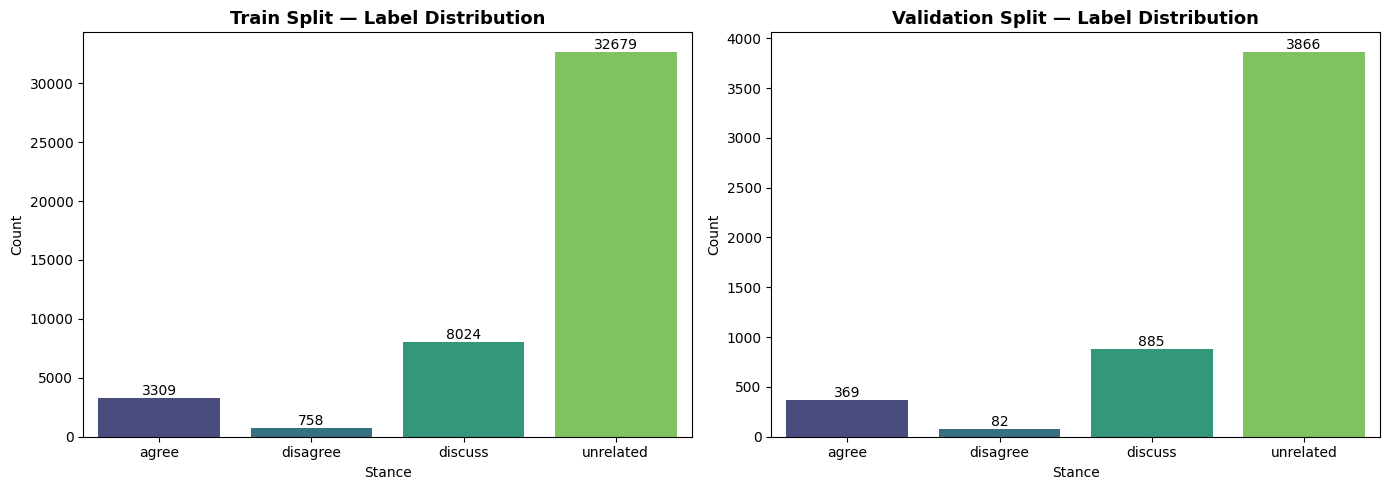

In [11]:
print("=== Train Split Distribution ===")
print(df_train_split["Stance"].value_counts())
print(f"\nPercentages:")
print((df_train_split["Stance"].value_counts(normalize=True) * 100).round(2))

print("\n=== Validation Split Distribution ===")
print(df_val_split["Stance"].value_counts())
print(f"\nPercentages:")
print((df_val_split["Stance"].value_counts(normalize=True) * 100).round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["agree", "disagree", "discuss", "unrelated"]

sns.countplot(data=df_train_split, x="Stance", order=order, ax=axes[0], palette="viridis")
axes[0].set_title("Train Split — Label Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Stance")
axes[0].set_ylabel("Count")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d")

sns.countplot(data=df_val_split, x="Stance", order=order, ax=axes[1], palette="viridis")
axes[1].set_title("Validation Split — Label Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Stance")
axes[1].set_ylabel("Count")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

# Longformer Initialization

Load tokenizer dan model dari `allenai/longformer-base-4096` dengan konfigurasi 4 label untuk multi-class classification.

In [12]:
MODEL_NAME = "allenai/longformer-base-4096"

tokenizer = LongformerTokenizerFast.from_pretrained(MODEL_NAME)

model = LongformerForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    label2id=label2id,
    id2label=id2label,
)

model.to(device)

print(f"Model: {MODEL_NAME}")
print(f"Num labels: {model.config.num_labels}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of LongformerForSequenceClassification were not initialized from the model checkpoint at allenai/longformer-base-4096 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: allenai/longformer-base-4096
Num labels: 4
Model parameters: 148,662,532
Trainable parameters: 148,662,532


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


# Token Length Analysis

Analisis panjang token sebelum menentukan MAX_LENGTH untuk tokenisasi. Menggunakan tokenizer Longformer untuk menghitung jumlah token pada headline, article body, dan gabungan keduanya.

Calculating token lengths (this may take a moment)...

--- Headline Token Length ---
Mean:   15.7
Median: 15.0
Max:    83
P95:    26.0
P99:    36.0

--- Article Token Length ---
Mean:   477.9
Median: 392.0
Max:    5889
P95:    1167.0
P99:    1821.0

--- Combined Token Length ---
Mean:   497.6
Median: 411.0
Max:    5919
P95:    1192.0
P99:    1842.0


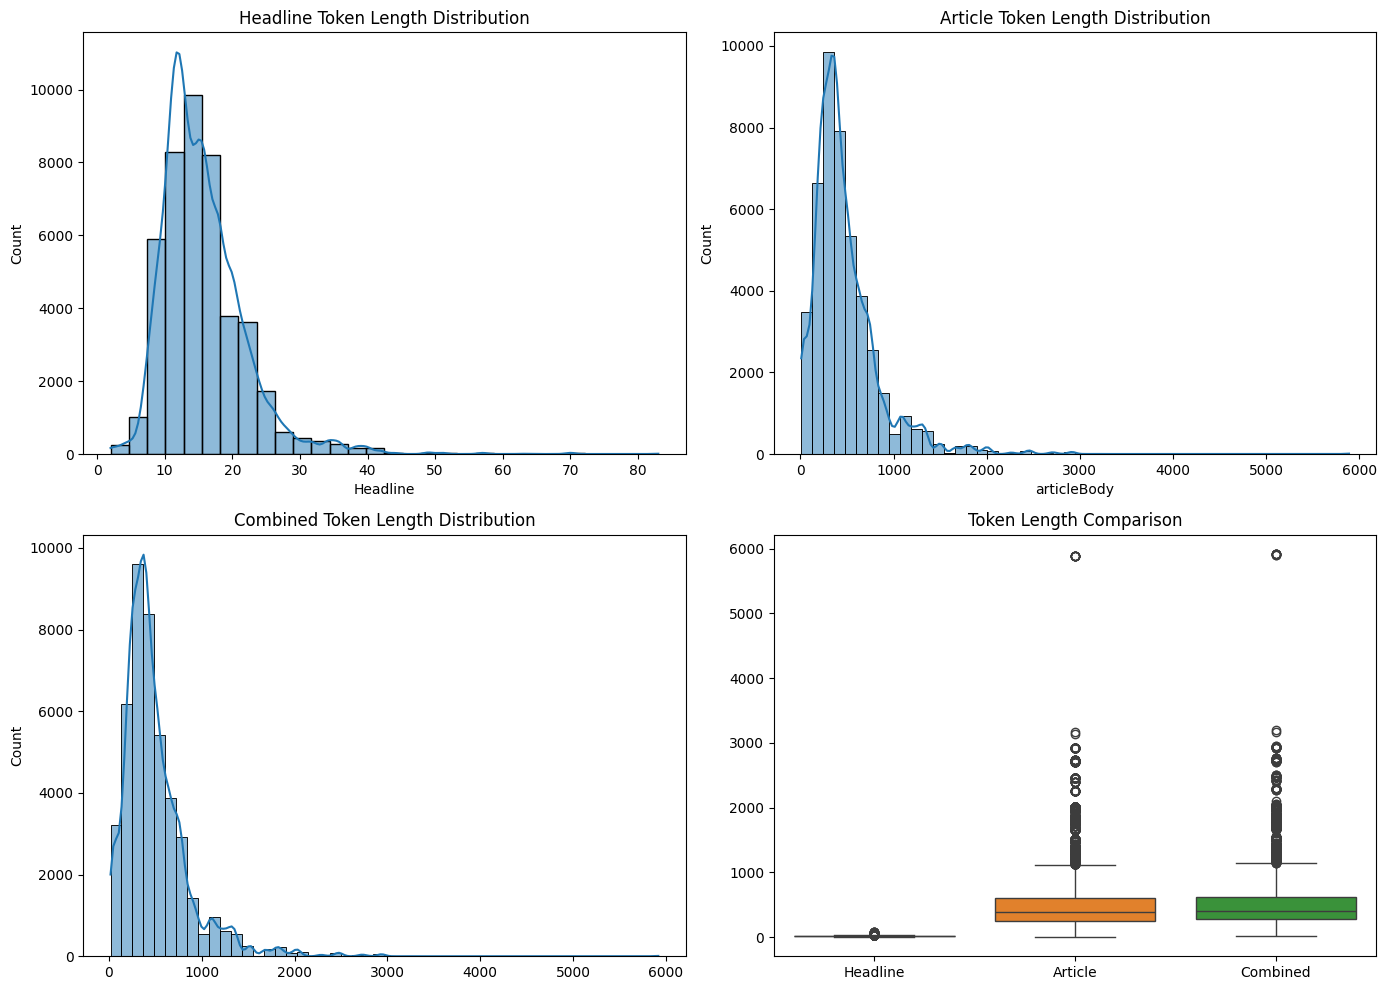

In [13]:
def count_tokens(text):
    """Count tokens for a given text using the loaded tokenizer."""
    return len(tokenizer.encode(str(text), add_special_tokens=False))

# Sample for analysis (use full train split)
print("Calculating token lengths (this may take a moment)...")

headline_tokens = df_train_split["Headline"].apply(count_tokens)
article_tokens = df_train_split["articleBody"].apply(count_tokens)
# Combined: headline + sep + article + special tokens (~4 tokens overhead)
combined_tokens = headline_tokens + article_tokens + 4

def report_token_stats(series, name):
    print(f"\n--- {name} ---")
    print(f"Mean:   {series.mean():.1f}")
    print(f"Median: {series.median():.1f}")
    print(f"Max:    {series.max()}")
    print(f"P95:    {np.percentile(series, 95):.1f}")
    print(f"P99:    {np.percentile(series, 99):.1f}")

report_token_stats(headline_tokens, "Headline Token Length")
report_token_stats(article_tokens, "Article Token Length")
report_token_stats(combined_tokens, "Combined Token Length")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(headline_tokens, bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Headline Token Length Distribution")

sns.histplot(article_tokens, bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Article Token Length Distribution")

sns.histplot(combined_tokens, bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Combined Token Length Distribution")

sns.boxplot(data=pd.DataFrame({
    "Headline": headline_tokens,
    "Article": article_tokens,
    "Combined": combined_tokens,
}), ax=axes[1, 1])
axes[1, 1].set_title("Token Length Comparison")

plt.tight_layout()
plt.show()

# Dynamic Max Length Selection

Nilai `MAX_LENGTH` menentukan panjang maksimum token yang akan diproses oleh model. Nilai ini sebaiknya disesuaikan berdasarkan hasil analisis token length di atas.

Pertimbangan:
- Nilai yang terlalu besar membutuhkan lebih banyak GPU memory dan waktu training
- Nilai yang terlalu kecil akan memotong (truncate) banyak artikel
- Longformer mendukung hingga 4096 token
- Pilih nilai yang mencakup mayoritas data (misal P95 atau P99)

In [14]:
# Adjust this value based on Token Length Analysis results
MAX_LENGTH = 1024

print(f"MAX_LENGTH: {MAX_LENGTH}")
print(f"Percentage of combined tokens within MAX_LENGTH: "
      f"{(combined_tokens <= MAX_LENGTH).mean() * 100:.2f}%")

MAX_LENGTH: 1024
Percentage of combined tokens within MAX_LENGTH: 92.35%


# Global Attention Configuration

Longformer menggunakan kombinasi local attention dan global attention. Global attention memungkinkan token tertentu untuk attend ke semua token lainnya.

Mode yang didukung:
- `cls_only`: Hanya token CLS yang mendapat global attention
- `headline_and_cls`: Token CLS dan semua token headline mendapat global attention (direkomendasikan untuk stance detection karena headline adalah referensi utama)

In [15]:
# Global attention mode: "cls_only" or "headline_and_cls"
GLOBAL_ATTENTION_MODE = "headline_and_cls"

print(f"Global attention mode: {GLOBAL_ATTENTION_MODE}")

Global attention mode: headline_and_cls


# Tokenization

Tokenisasi headline dan article body menggunakan Longformer tokenizer. Headline dan article body digabungkan sebagai input pair (text, text_pair) sehingga tokenizer otomatis menambahkan separator token.

In [16]:
def tokenize_and_prepare(df, has_labels=True):
    """
    Tokenize dataframe and prepare global attention masks.

    Args:
        df: DataFrame with 'Headline' and 'articleBody' columns
        has_labels: Whether the dataframe has 'label' column

    Returns:
        dict with input_ids, attention_mask, global_attention_mask, and optionally labels
    """
    # Tokenize headline + article as text pair
    encodings = tokenizer(
        df["Headline"].astype(str).tolist(),
        df["articleBody"].astype(str).tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors=None,
    )

    # Generate global attention masks
    global_attention_masks = []
    for i, input_ids in enumerate(encodings["input_ids"]):
        global_attn = [0] * len(input_ids)

        if GLOBAL_ATTENTION_MODE == "cls_only":
            # Only CLS token gets global attention
            global_attn[0] = 1

        elif GLOBAL_ATTENTION_MODE == "headline_and_cls":
            # CLS token gets global attention
            global_attn[0] = 1
            # All headline tokens get global attention (tokens before first </s>)
            for j, token_id in enumerate(input_ids):
                if j == 0:
                    continue
                if token_id == tokenizer.sep_token_id:
                    break
                global_attn[j] = 1
        else:
            raise ValueError(f"Unknown global attention mode: {GLOBAL_ATTENTION_MODE}")

        global_attention_masks.append(global_attn)

    result = {
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "global_attention_mask": global_attention_masks,
    }

    if has_labels:
        result["labels"] = df["label"].tolist()

    return result

print("Tokenizing train split...")
train_encodings = tokenize_and_prepare(df_train_split, has_labels=True)

print("Tokenizing validation split...")
val_encodings = tokenize_and_prepare(df_val_split, has_labels=True)

print("Tokenizing test set...")
test_encodings = tokenize_and_prepare(df_test, has_labels=False)

print("\nTokenization complete.")
print(f"Train samples: {len(train_encodings['input_ids'])}")
print(f"Validation samples: {len(val_encodings['input_ids'])}")
print(f"Test samples: {len(test_encodings['input_ids'])}")

Tokenizing train split...
Tokenizing validation split...
Tokenizing test set...

Tokenization complete.
Train samples: 44770
Validation samples: 5202
Test samples: 25413


# Hugging Face Dataset

Konversi hasil tokenisasi ke format Hugging Face Dataset dan set format PyTorch.

In [17]:
train_dataset = Dataset.from_dict(train_encodings)
val_dataset = Dataset.from_dict(val_encodings)
test_dataset = Dataset.from_dict(test_encodings)

# Set PyTorch format
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "global_attention_mask", "labels"],
)
val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "global_attention_mask", "labels"],
)
test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "global_attention_mask"],
)

print(f"Train dataset: {train_dataset}")
print(f"Validation dataset: {val_dataset}")
print(f"Test dataset: {test_dataset}")

Train dataset: Dataset({
    features: ['input_ids', 'attention_mask', 'global_attention_mask', 'labels'],
    num_rows: 44770
})
Validation dataset: Dataset({
    features: ['input_ids', 'attention_mask', 'global_attention_mask', 'labels'],
    num_rows: 5202
})
Test dataset: Dataset({
    features: ['input_ids', 'attention_mask', 'global_attention_mask'],
    num_rows: 25413
})


# Class Weight Analysis

Menghitung bobot kelas berdasarkan distribusi label di training set. Bobot ini dapat digunakan untuk menangani class imbalance.

In [18]:
train_labels = np.array(df_train_split["label"].tolist())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels,
)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("=== Class Frequencies ===")
for label_id in sorted(id2label.keys()):
    count = (train_labels == label_id).sum()
    pct = count / len(train_labels) * 100
    print(f"  {id2label[label_id]:>10s} (id={label_id}): {count:>6d} ({pct:.2f}%)")

print("\n=== Class Weights ===")
for label_id in sorted(id2label.keys()):
    print(f"  {id2label[label_id]:>10s} (id={label_id}): {class_weights[label_id]:.4f}")

# Store as tensor for potential custom loss usage
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"\nClass weights tensor: {class_weights_tensor}")

=== Class Frequencies ===
       agree (id=0):   3309 (7.39%)
    disagree (id=1):    758 (1.69%)
     discuss (id=2):   8024 (17.92%)
   unrelated (id=3):  32679 (72.99%)

=== Class Weights ===
       agree (id=0): 3.3824
    disagree (id=1): 14.7658
     discuss (id=2): 1.3949
   unrelated (id=3): 0.3425

Class weights tensor: tensor([ 3.3824, 14.7658,  1.3949,  0.3425], device='cuda:0')


# Metrics Function

Fungsi `compute_metrics()` untuk evaluasi model selama training. Menghitung accuracy, precision, recall, F1 macro, dan F1 weighted.

In [19]:
def compute_metrics(eval_pred):
    """
    Compute evaluation metrics for the Trainer.

    Args:
        eval_pred: EvalPrediction object with predictions and label_ids

    Returns:
        dict with accuracy, precision_macro, recall_macro, f1_macro, f1_weighted
    """
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision_macro": precision_score(labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
    }

print("compute_metrics() defined.")

compute_metrics() defined.


# Training Configuration

Konfigurasi `TrainingArguments` untuk Hugging Face Trainer. Parameter dapat disesuaikan berdasarkan GPU yang tersedia dan kebutuhan training.

In [40]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    num_train_epochs=3,
    fp16=True,
    eval_strategy="epoch",
    gradient_checkpointing=True,
    eval_accumulation_steps=4,
    save_strategy="epoch",
        load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
    seed=SEED,
    report_to="none",
    dataloader_num_workers=0,
    remove_unused_columns=False,
)

print("=== Training Configuration ===")
print(f"Batch size (per device): {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Weight decay: {training_args.weight_decay}")
print(f"Warmup ratio: {training_args.warmup_ratio}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"FP16: {training_args.fp16}")
print(f"Best model metric: {training_args.metric_for_best_model}")

=== Training Configuration ===
Batch size (per device): 4
Gradient accumulation: 16
Effective batch size: 64
Learning rate: 2e-05
Weight decay: 0.01
Warmup ratio: 0.1
Epochs: 3
FP16: True
Best model metric: f1_macro


# Early Stopping

Callback untuk menghentikan training lebih awal jika metrik evaluasi tidak membaik setelah beberapa epoch.

In [41]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.0,
)

print(f"Early stopping patience: {early_stopping.early_stopping_patience}")

Early stopping patience: 2


# Trainer Initialization

Inisialisasi Hugging Face Trainer dengan model, tokenizer, dataset, metrics, dan callbacks.

In [42]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
)

print("Trainer initialized successfully.")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Eval dataset size: {len(val_dataset)}")

Trainer initialized successfully.
Train dataset size: 44770
Eval dataset size: 5202


# Training

Eksekusi training model Longformer. Proses ini akan:
1. Training selama beberapa epoch sesuai konfigurasi
2. Evaluasi di setiap akhir epoch
3. Menyimpan checkpoint terbaik berdasarkan F1 macro
4. Menghentikan training lebih awal jika tidak ada peningkatan (early stopping)

In [43]:
start_time = time.time()


import os
from transformers.trainer_utils import get_last_checkpoint

# Cek apakah ada checkpoint sebelumnya di folder output
last_checkpoint = None
if os.path.isdir(OUTPUT_DIR):
    last_checkpoint = get_last_checkpoint(OUTPUT_DIR)

if last_checkpoint is not None:
    print(f"Melanjutkan training dari checkpoint: {last_checkpoint}")
    train_result = trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("Memulai training dari awal...")
    train_result = trainer.train()

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time / 60:.2f} minutes")
print(f"\n=== Training Results ===")
for key, value in train_result.metrics.items():
    print(f"  {key}: {value}")

Memulai training dari awal...


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.104700,0.160803,0.953287,0.871181,0.745659,0.775112,0.951539
2,0.043100,0.125259,0.967320,0.855198,0.855603,0.855390,0.967323
3,0.023100,0.147716,0.967897,0.860709,0.860444,0.860488,0.967831



Training completed in 1181.10 minutes

=== Training Results ===
  train_runtime: 70864.7708
  train_samples_per_second: 1.895
  train_steps_per_second: 0.03
  total_flos: 8.82230091190272e+16
  train_loss: 0.11717590701012384
  epoch: 3.0


# Training Curves

Visualisasi training history dari Trainer untuk mendeteksi overfitting secara visual.

Plot yang dihasilkan:
1. **Training Loss vs Epoch** — apakah model masih belajar
2. **Validation Loss vs Epoch** — apakah model mulai overfitting
3. **Validation F1 Macro vs Epoch** — trend performa model pada validation

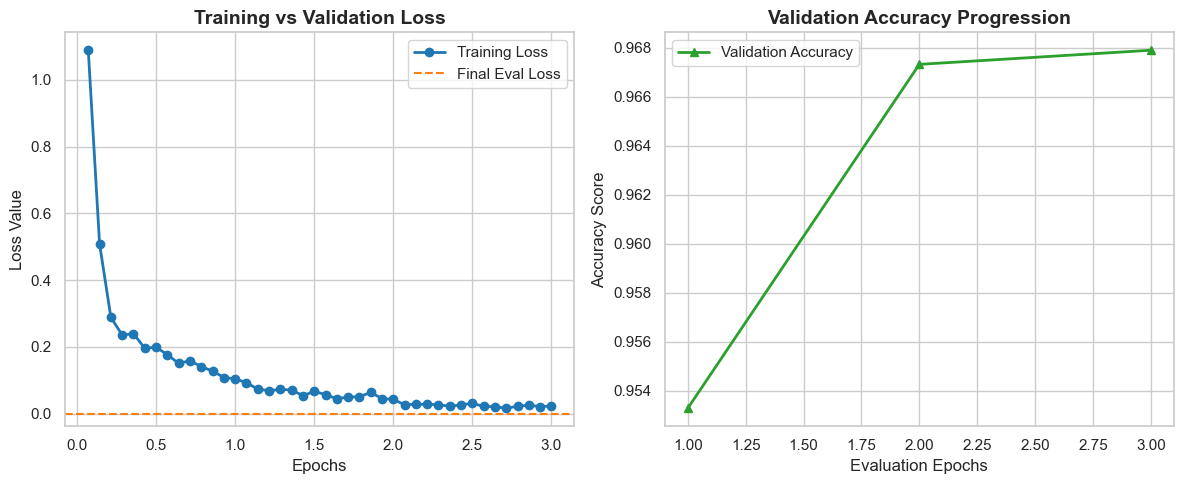

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set tema visual grafis
sns.set_theme(style="whitegrid")

# 1. Ekstrak data historis dari objek Hugging Face Trainer
history = trainer.state.log_history

train_loss, val_loss = [], []
train_acc, val_acc = [], []
epochs_loss, epochs_acc = [], []

for log in history:
    if 'epoch' in log:
        # Mengambil metrik loss
        if 'loss' in log:  # Ini adalah Training Loss
            train_loss.append(log['loss'])
            epochs_loss.append(log['epoch'])
        if 'eval_loss' in log:  # Ini adalah Validation Loss
            val_loss.append(log['eval_loss'])
        
        # Mengambil metrik akurasi (jika Anda menyertakan compute_metrics)
        if 'eval_accuracy' in log:
            val_acc.append(log['eval_accuracy'])

# 2. Plot Grafik Loss (Indikator Utama Overfitting)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_loss, train_loss, label='Training Loss', color='#1f77b4', linewidth=2, marker='o')
# Jika panjang val_loss sama dengan epochs_loss (dievaluasi per epoch)
if len(val_loss) == len(epochs_loss):
    plt.plot(epochs_loss, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s')
else:
    # Jika evaluasi hanya di akhir atau interval tertentu
    plt.axhline(y=history[-1].get('eval_loss', 0) if history else 0, color='#ff7f0e', linestyle='--', label='Final Eval Loss')

plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(fontsize=11)

# 3. Interpretasi Visual Langsung di Grafik
plt.subplot(1, 2, 2)
if val_acc:
    plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='#2ca02c', linewidth=2, marker='^')
plt.title('Validation Accuracy Progression', fontsize=14, fontweight='bold')
plt.xlabel('Evaluation Epochs', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Overfitting Analysis

## Tanda-tanda Overfitting

Perhatikan training curves di atas untuk mendeteksi overfitting:

### Indikasi Overfitting:
1. **Training loss terus menurun** — model terus belajar pola dari training data
2. **Validation loss mulai meningkat** — model gagal menggeneralisasi ke data baru dan mulai "menghafal" training data
3. **Validation F1 Macro stagnan atau menurun** — performa pada data yang belum pernah dilihat tidak lagi membaik

### Divergensi Train-Val Loss:
- Jika gap antara training loss dan validation loss semakin membesar seiring epoch, ini adalah sinyal kuat overfitting
- Model yang sehat menunjukkan kedua kurva menurun secara bersamaan

### Mitigasi Overfitting:
- **Early stopping** sudah diimplementasikan (patience=2)
- **Weight decay** (L2 regularization) = 0.01
- **Warmup ratio** = 0.1 untuk stabilitas awal training
- Pertimbangkan **mengurangi learning rate** jika overfitting terdeteksi
- Pertimbangkan **menambah dropout** atau **mengurangi epoch**

### Catatan Penting:
Dengan perbaikan data leakage (GroupShuffleSplit pada Body ID), validation metrics sekarang mencerminkan performa model yang sesungguhnya. Metrik sebelumnya (sebelum fix) kemungkinan terlalu optimistik karena model bisa "menghafal" artikel body yang sama.

# Validation Evaluation

Evaluasi model pada validation set untuk melihat performa sebelum evaluasi pada test set.

In [45]:
print("Evaluating on validation set...")

val_predictions = trainer.predict(val_dataset)
val_preds = np.argmax(val_predictions.predictions, axis=-1)
val_labels = np.array(df_val_split["label"].tolist())

# Classification report
target_names = [id2label[i] for i in range(4)]
print("\n=== Validation Classification Report ===")
print(classification_report(val_labels, val_preds, target_names=target_names, digits=4))

# Key metrics
print(f"Accuracy:    {accuracy_score(val_labels, val_preds):.4f}")
print(f"Precision:   {precision_score(val_labels, val_preds, average='macro'):.4f}")
print(f"Recall:      {recall_score(val_labels, val_preds, average='macro'):.4f}")
print(f"F1 Macro:    {f1_score(val_labels, val_preds, average='macro'):.4f}")
print(f"F1 Weighted: {f1_score(val_labels, val_preds, average='weighted'):.4f}")

# Confusion matrix
val_cm = confusion_matrix(val_labels, val_preds)
print("\n=== Validation Confusion Matrix ===")
print(val_cm)

Evaluating on validation set...



=== Validation Classification Report ===
              precision    recall  f1-score   support

       agree     0.8431    0.8157    0.8292       369
    disagree     0.6905    0.7073    0.6988        82
     discuss     0.9105    0.9198    0.9151       885
   unrelated     0.9987    0.9990    0.9988      3866

    accuracy                         0.9679      5202
   macro avg     0.8607    0.8604    0.8605      5202
weighted avg     0.9678    0.9679    0.9678      5202

Accuracy:    0.9679
Precision:   0.8607
Recall:      0.8604
F1 Macro:    0.8605
F1 Weighted: 0.9678

=== Validation Confusion Matrix ===
[[ 301    9   58    1]
 [   5   58   18    1]
 [  51   17  814    3]
 [   0    0    4 3862]]


# Test Evaluation

Evaluasi model pada test set. Catatan: test set FNC-1 yang tersedia mungkin tidak memiliki label (unlabeled). Jika kolom Stance tersedia di test set, evaluasi akan dilakukan. Jika tidak, hanya prediksi yang dihasilkan.

In [46]:
print("Evaluating on test set...")

test_predictions = trainer.predict(test_dataset)
test_preds = np.argmax(test_predictions.predictions, axis=-1)
test_pred_labels = [id2label[p] for p in test_preds]

# Check if test set has labels
if "Stance" in df_test.columns:
    df_test["label"] = df_test["Stance"].map(label2id)
    test_labels = np.array(df_test["label"].tolist())

    target_names = [id2label[i] for i in range(4)]
    print("\n=== Test Classification Report ===")
    print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))

    print(f"Accuracy:    {accuracy_score(test_labels, test_preds):.4f}")
    print(f"Precision:   {precision_score(test_labels, test_preds, average='macro'):.4f}")
    print(f"Recall:      {recall_score(test_labels, test_preds, average='macro'):.4f}")
    print(f"F1 Macro:    {f1_score(test_labels, test_preds, average='macro'):.4f}")
    print(f"F1 Weighted: {f1_score(test_labels, test_preds, average='weighted'):.4f}")

    test_cm = confusion_matrix(test_labels, test_preds)
    print("\n=== Test Confusion Matrix ===")
    print(test_cm)
else:
    print("Test set does not have Stance labels. Showing prediction distribution only.")
    print(pd.Series(test_pred_labels).value_counts())

Evaluating on test set...


Test set does not have Stance labels. Showing prediction distribution only.
unrelated    18341
discuss       4679
agree         1900
disagree       493
Name: count, dtype: int64


# Error Analysis

Menampilkan 20 sampel yang salah diklasifikasi untuk analisis kesalahan model.

In [47]:
def error_analysis(df, true_labels, pred_labels, id2label, n=20):
    """
    Display top N misclassified samples.

    Args:
        df: Original dataframe
        true_labels: Array of true label ids
        pred_labels: Array of predicted label ids
        id2label: Mapping from id to label name
        n: Number of samples to display
    """
    misclassified = np.where(true_labels != pred_labels)[0]
    print(f"Total misclassified: {len(misclassified)} / {len(true_labels)} "
          f"({len(misclassified) / len(true_labels) * 100:.2f}%)")

    sample_indices = misclassified[:n]
    print(f"\nShowing top {len(sample_indices)} misclassified samples:\n")

    for rank, idx in enumerate(sample_indices, 1):
        headline = str(df.iloc[idx]["Headline"])
        body = str(df.iloc[idx]["articleBody"])[:200]
        true = id2label[true_labels[idx]]
        pred = id2label[pred_labels[idx]]

        print(f"--- Sample {rank} (index {idx}) ---")
        print(f"True: {true:>10s}  |  Predicted: {pred:>10s}")
        print(f"Headline: {headline}")
        print(f"Article:  {body}...")
        print()

# Run error analysis on validation set
error_analysis(df_val_split, val_labels, val_preds, id2label, n=20)

Total misclassified: 167 / 5202 (3.21%)

Showing top 20 misclassified samples:

--- Sample 1 (index 203) ---
True:      agree  |  Predicted:    discuss
Headline: Texas Truck Winds Up in Syria With Islamic Militants
Article:  TEXAS CITY, Texas (AP) — A Texas plumber is getting some unwanted attention after one of his old company vehicles appeared in a photo posted on an Islamic militant group's social media account. Mark-1...

--- Sample 2 (index 272) ---
True:    discuss  |  Predicted:      agree
Headline: Tiger Woods is not on suspension for failing a drug test, his agent and a PGA official say
Article:  PGA golfer Dan Olsen told WVFN that he has learned that Tiger Woods failed a drug test for performance enhancing drugs and has been suspended by the PGA. Dan Olsen: “Well, I’ve heard that he’s suspend...

--- Sample 3 (index 277) ---
True:      agree  |  Predicted:    discuss
Headline: DNA test confirms child is IS head Abu Bakr al-Baghdadi's daughter
Article:  BEIRUT: Lebanon's inter

# Confusion Matrix Visualization

Visualisasi confusion matrix menggunakan seaborn heatmap.

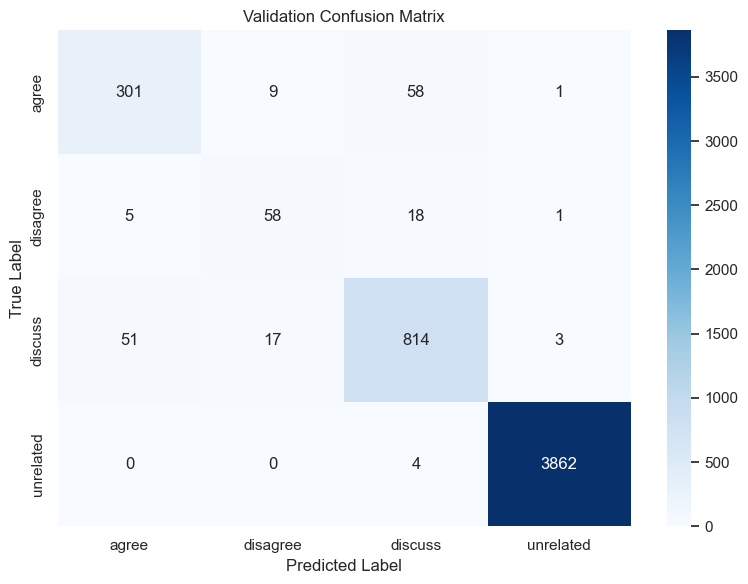

In [48]:
def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    """
    Plot confusion matrix as a seaborn heatmap.

    Args:
        cm: Confusion matrix array
        labels: List of label names
        title: Plot title
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

target_names = [id2label[i] for i in range(4)]

# Validation confusion matrix
plot_confusion_matrix(val_cm, target_names, title="Validation Confusion Matrix")

# Test confusion matrix (if labels available)
if "Stance" in df_test.columns:
    plot_confusion_matrix(test_cm, target_names, title="Test Confusion Matrix")

# Model Saving

Menyimpan model, tokenizer, dan konfigurasi label ke output directory.

In [49]:
save_dir = Path(OUTPUT_DIR)
save_dir.mkdir(parents=True, exist_ok=True)

# Save model and tokenizer
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

# Save label mappings
label_config = {
    "label2id": label2id,
    "id2label": {str(k): v for k, v in id2label.items()},
}
with open(save_dir / "label_config.json", "w") as f:
    json.dump(label_config, f, indent=2)

# Save training configuration summary
train_config = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "global_attention_mode": GLOBAL_ATTENTION_MODE,
    "batch_size": training_args.per_device_train_batch_size,
    "gradient_accumulation_steps": training_args.gradient_accumulation_steps,
    "learning_rate": training_args.learning_rate,
    "weight_decay": training_args.weight_decay,
    "warmup_ratio": training_args.warmup_ratio,
    "num_epochs": training_args.num_train_epochs,
    "fp16": training_args.fp16,
    "seed": SEED,
    "environment": ENVIRONMENT,
    "split_strategy": "GroupShuffleSplit on Body ID",
}
with open(save_dir / "training_config.json", "w") as f:
    json.dump(train_config, f, indent=2)

print(f"Model saved to: {save_dir}")
print(f"Files saved:")
for f_path in sorted(save_dir.iterdir()):
    print(f"  {f_path.name}")

Model saved to: artifacts\model-longformer
Files saved:
  checkpoint-1400
  checkpoint-2100
  config.json
  label_config.json
  merges.txt
  model.safetensors
  special_tokens_map.json
  tokenizer.json
  tokenizer_config.json
  training_config.json
  vocab.json


# Inference Example

Fungsi `predict_stance()` untuk prediksi stance pada input baru. Dapat digunakan untuk inferensi setelah model selesai ditraining.

In [50]:
def predict_stance(headline, article_body, model=model, processing_class=tokenizer):
    """
    Predict stance for a headline-article pair.

    Args:
        headline: News headline text
        article_body: News article body text
        model: Trained LongformerForSequenceClassification
        tokenizer: LongformerTokenizerFast

    Returns:
        tuple: (predicted_label, confidence_score)
    """
    model.eval()

    # Tokenize
    inputs = tokenizer(
        str(headline),
        str(article_body),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    # Generate global attention mask
    input_ids = inputs["input_ids"][0].tolist()
    global_attn = [0] * len(input_ids)

    if GLOBAL_ATTENTION_MODE == "cls_only":
        global_attn[0] = 1
    elif GLOBAL_ATTENTION_MODE == "headline_and_cls":
        global_attn[0] = 1
        for j, token_id in enumerate(input_ids):
            if j == 0:
                continue
            if token_id == tokenizer.sep_token_id:
                break
            global_attn[j] = 1

    inputs["global_attention_mask"] = torch.tensor([global_attn])

    # Move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_id].item()

    predicted_label = id2label[pred_id]
    return predicted_label, confidence


# Example usage
example_headline = "NASA Confirms Evidence of Water on Mars"
example_body = (
    "Scientists at NASA have announced new findings that suggest the presence "
    "of liquid water on the surface of Mars. The discovery was made using data "
    "from the Mars Reconnaissance Orbiter, which detected hydrated salts on "
    "slopes where mysterious streaks are seen."
)

label, confidence = predict_stance(example_headline, example_body)
print(f"Headline:   {example_headline}")
print(f"Predicted:  {label}")
print(f"Confidence: {confidence:.4f}")

Headline:   NASA Confirms Evidence of Water on Mars
Predicted:  discuss
Confidence: 0.9908


# Final Summary

## Model Configuration

| Parameter | Value |
|---|---|
| Model | allenai/longformer-base-4096 |
| Task | Multi-Class Classification (4 classes) |
| Labels | agree, disagree, discuss, unrelated |
| MAX_LENGTH | 1024 (adjustable based on EDA) |
| Global Attention | headline_and_cls |
| Data Split | GroupShuffleSplit on Body ID (leakage-free) |

## Training Configuration

| Parameter | Value |
|---|---|
| Batch Size (per device) | 2 |
| Gradient Accumulation | 8 |
| Effective Batch Size | 16 |
| Learning Rate | 2e-5 |
| Weight Decay | 0.01 |
| Warmup Ratio | 0.1 |
| Epochs | 3 (max) |
| Early Stopping | patience=2 |
| FP16 | True |
| Best Model Metric | F1 Macro |

## Evaluation Metrics

- Accuracy
- Precision (Macro)
- Recall (Macro)
- F1 Score (Macro)
- F1 Score (Weighted)
- Classification Report (per class)
- Confusion Matrix

## Data Leakage Fix

- **Before:** `train_test_split` on rows → 99.76% Body ID leakage
- **After:** `GroupShuffleSplit` on Body ID → 0% leakage (verified)